In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import os
import re
import json 

In [20]:

def get_error_estimation_fft(data, N_remove, N_estimate, link, normalize_data, save_figures=False, save_path=None, show_figs = False):
    print(f'Estimating for link {link}')
    # Extract the error values
    dates = data['Date']

    if normalize_data:
        max_value = max(data['Error'].values)
        data_values = np.floor((data['Error'].values /max_value) * 100)
    else:
        data_values = data['Error'].values 
   
    # Number of samples
    N = len(data_values)
    

    # Split the data
    if N_remove == 0:
        past_data_values = data_values
        past_dates = dates
        last_date = past_dates.iloc[-1]
        future_data_values =  pd.date_range(start=last_date, periods=N_estimate + 1, freq='D')[1:]
    else: 
        past_data_values = data_values[:-N_remove] # All the error values except for the last N_remove days
        future_data_values = data_values[-N_remove:] # The last N_remove error values
        past_dates = dates[:-N_remove] # All the error values except for the last N_remove days

    
    # testing_dates = dates[-N_remove:] # The last N_remove dates
   
    # Sample spacing (assuming daily data)
    T = 1.0

    # Apply the Fourier transform to the training data
    yf = fft(past_data_values)
    xf = fftfreq(len(past_data_values), T) # Computes the corresponding frequency bins

    # Remove outliers
    magnitude_threshold = np.percentile(np.abs(yf), 90)
    filtered_yf = yf * (np.abs(yf) > magnitude_threshold)

    # Estimate errors
    extended_yf_past = np.zeros(len(past_data_values) + N_remove, dtype=complex)
    extended_yf_past[:len(past_data_values)] = filtered_yf
    estimated_data = ifft(extended_yf_past).real
    estimated_data_past = estimated_data[:-N_remove]
    estimated_data_future = estimated_data[len(past_data_values):]

    # Generate future dates
    last_date = past_dates.iloc[-1]
    future_dates = pd.date_range(start=last_date, periods=N_estimate + 1, freq='D')[1:]

    # Calculate error metrics of the entire dataset
    error_of_fft = abs(data_values - estimated_data)
    mean_fft_error = np.mean(error_of_fft)
    std_fft_error = np.std(error_of_fft)
    rmse_fft_error = root_mean_squared_error(data_values, estimated_data)

    # Calculate error metrics of the future estimation
    error_of_future_estimation = abs(future_data_values - estimated_data_future)
    mean_error_future_estimation = np.mean(error_of_future_estimation)
    std_error_future_estimation = np.std(error_of_future_estimation)
    rmse_error_future_estimation = root_mean_squared_error(future_data_values, estimated_data_future)

    # Calculate error metrics of the past estimation
    error_of_past_estimation = abs(past_data_values - estimated_data_past)
    mean_error_past_estimation = np.mean(error_of_past_estimation)
    std_error_past_estimation = np.std(error_of_past_estimation)
    rmse_error_past_estimation = root_mean_squared_error(past_data_values, estimated_data_past)

    result = {
        link: {
            "Normalized_data": normalize_data,

            "Complete_dates": dates,
            "Complete_data": data_values,
            "Complete_estimated_data": estimated_data,

            "Complete_estimation_error": error_of_fft,
            "Complete_mean_estimation_error": mean_fft_error,
            "Complete_std_estimation_error": std_fft_error,
            "Complete_rmse_estimation_error": rmse_fft_error,

            
            "Past_dates": past_dates,
            "Last_date": last_date,
            "Past_data": past_data_values,
            "Past_estimated_data": estimated_data_past,

            "Past_estimation_error": error_of_past_estimation,
            "Past_mean_estimation_error": mean_error_past_estimation,
            "Past_std_estimation_error": std_error_past_estimation,
            "Past_rmse_estimation_error": rmse_error_past_estimation,


            "Future_dates": future_dates,
            "Future_data": future_data_values,
            "Future_estimated_data": estimated_data_future,

            "Future_estimation_error": error_of_future_estimation,
            "Future_mean_estimation_error": mean_error_future_estimation,
            "Future_std_estimation_error": std_error_future_estimation,
            "Future_rmse_estimation_error": rmse_error_future_estimation
        }
    }

    if show_figs or save_figures:
        # Plotting
        plt.figure(figsize=(18, 30))

        # Plot for the FFT Magnitude Spectrum
        plt.subplot(10, 1, 1)
        plt.plot(xf, np.abs(yf), label='FFT Magnitude Spectrum')
        plt.title(f'Frequency Domain Representation (FFT) for link {link}')
        plt.xlabel('Frequency')
        plt.ylabel('Magnitude')
        plt.grid()
        plt.legend()

        #Complete data plot
        plt.subplot(10, 1, 2)
        plt.axvline(result[link]['Last_date'], color='r', linestyle=':', label='Forecast Start')
        plt.plot(result[link]['Complete_dates'], result[link]['Complete_data'], label='Actual Data', color='royalblue')
        plt.plot(result[link]['Complete_dates'], result[link]['Complete_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--')
        plt.title(f'Actual vs Estimated Data')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()

        #Complete error estimation plot
        plt.subplot(10, 1, 3)
        plt.axvline(result[link]['Last_date'], color='r', linestyle=':', label='Forecast Start')
        plt.plot(result[link]['Complete_dates'], result[link]['Complete_estimation_error'], label='Error of the Estimation', color='green')
        plt.axhline(result[link]['Complete_mean_estimation_error'], linestyle='dashed', label='Average Estimation Error', color='purple')
        plt.axhline(result[link]['Complete_rmse_estimation_error'], linestyle='dashed', label='Root Mean Squared Error', color='deeppink')
        plt.title(f'Prediction Error of Actual vs Estimated Data    Avg: {result[link]['Complete_mean_estimation_error']:.5f} RMSE:{result[link]['Complete_rmse_estimation_error']:.5f}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()

        # Complete upper and lower bounds
        plt.subplot(10, 1, 4)
        plt.axvline(result[link]['Last_date'], color='r', linestyle=':', label='Forecast Start')
        plt.plot(result[link]['Complete_dates'], result[link]['Complete_data']+result[link]['Complete_mean_estimation_error'], label='Upper Data Bound', color='teal')
        plt.plot(result[link]['Complete_dates'], result[link]['Complete_data']-result[link]['Complete_mean_estimation_error'], label='Lower Data Bound', color='orchid')
        plt.plot(result[link]['Complete_dates'], result[link]['Complete_estimated_data'], label='Estimated Data', color='chocolate', linestyle='--')
        plt.title(f'Bounds of Actual vs Estimated Data  std: {result[link]['Complete_std_estimation_error']}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()



        #Future data plot
        plt.subplot(10, 1, 5)
        plt.plot(result[link]['Future_dates'], result[link]['Future_data'], label='Actual Data', color='royalblue',  marker='o')
        plt.plot(result[link]['Future_dates'], result[link]['Future_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--', marker='x')
        plt.title(f'Actual vs Estimated Data for the future {N_remove} Days')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()

        #Future error estimation plot
        plt.subplot(10, 1, 6)
        plt.plot(result[link]['Future_dates'], result[link]['Future_estimation_error'], label='Error of the Estimation', color='green',  marker='o')
        plt.axhline(result[link]['Future_mean_estimation_error'], linestyle='dashed', label='Average Estimation Error', color='purple')
        plt.axhline(result[link]['Future_rmse_estimation_error'], linestyle='dashed', label='Root Mean Squared Error', color='deeppink')
        plt.title(f'Prediction Error of Actual vs Estimated Data for the future {N_remove} Days     Avg: {result[link]['Future_mean_estimation_error']:.5f} RMSE:{result[link]['Future_rmse_estimation_error']:.5f}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()

        # Future upper and lower bounds
        plt.subplot(10, 1, 7)
        plt.plot(result[link]['Future_dates'], result[link]['Future_data']+result[link]['Future_mean_estimation_error'], label='Upper Data Bound', color='teal',  marker='o')
        plt.plot(result[link]['Future_dates'], result[link]['Future_data']-result[link]['Future_mean_estimation_error'], label='Lower Data Bound', color='orchid',  marker='o')
        plt.plot(result[link]['Future_dates'], result[link]['Future_estimated_data'], label='Estimated Data', color='chocolate', linestyle='--',  marker='x')
        plt.title(f'Bounds of Actual vs Estimated Data for the future {N_remove} Days   std: {result[link]['Future_std_estimation_error']}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()



        #Past data plot
        plt.subplot(10, 1, 8)
        plt.plot(result[link]['Past_dates'], result[link]['Past_data'], label='Actual Data', color='royalblue')
        plt.plot(result[link]['Past_dates'], result[link]['Past_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--')
        plt.title(f'Actual vs Estimated Data for the past {N-N_remove} Days')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()

        #Past error estimation plot
        plt.subplot(10, 1, 9)
        plt.plot(result[link]['Past_dates'], result[link]['Past_estimation_error'], label='Error of the Estimation', color='green')
        plt.axhline(result[link]['Past_mean_estimation_error'], linestyle='dashed', label='Average Estimation Error', color='purple')
        plt.axhline(result[link]['Past_rmse_estimation_error'], linestyle='dashed', label='Root Mean Squared Error', color='deeppink')
        plt.title(f'Prediction Error of Actual vs Estimated Data for the past {N-N_remove} Days     Avg: {result[link]['Past_mean_estimation_error']:.5f}  RMSE:{result[link]['Past_rmse_estimation_error']:.5f}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()

        # Past upper and lower bounds
        plt.subplot(10, 1, 10)
        plt.plot(result[link]['Past_dates'], result[link]['Past_data']+result[link]['Past_mean_estimation_error'], label='Upper Data Bound', color='teal')
        plt.plot(result[link]['Past_dates'], result[link]['Past_data']-result[link]['Past_mean_estimation_error'], label='Lower Data Bound', color='orchid')
        plt.plot(result[link]['Past_dates'], result[link]['Past_estimated_data'], label='Estimated Data', color='chocolate', linestyle='--')
        plt.title(f'Bounds of Actual vs Estimated Data for the past {N-N_remove} Days   std: {result[link]['Past_std_estimation_error']}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()


        plt.tight_layout()
        if save_figures:
            plt.savefig(save_path)
            plt.close()
        
        else: 
            plt.show()



    result[link]["Complete_dates"] = result[link]["Complete_dates"].to_list()
    result[link]["Past_dates"] = result[link]["Past_dates"].to_list()
    result[link]["Future_dates"] = result[link]["Future_dates"].to_list()
    
    for key in result:
        result[key]['Complete_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Complete_dates']]
        result[key]['Past_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Past_dates']]
        result[key]['Future_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Future_dates']]
        result[key]['Last_date'] = result[key]['Last_date'].strftime('%Y-%m-%d')

    result[link]["Complete_data"] = result[link]["Complete_data"].tolist()
    result[link]["Complete_estimated_data"] = result[link]["Complete_estimated_data"].tolist()
    result[link]["Complete_estimation_error"] = result[link]["Complete_estimation_error"].tolist()
    result[link]["Past_data"] = result[link]["Past_data"].tolist()
    result[link]["Past_estimated_data"] = result[link]["Past_estimated_data"].tolist()
    result[link]["Past_estimation_error"] = result[link]["Past_estimation_error"].tolist()
    result[link]["Future_data"] = result[link]["Future_data"].tolist()
    result[link]["Future_estimated_data"] = result[link]["Future_estimated_data"].tolist()
    result[link]["Future_estimation_error"] = result[link]["Future_estimation_error"].tolist()

    # result[link]["yf"] = result[link]["yf"].tolist()
    # result[link]["xf"] = result[link]["xf"].tolist()

    return result


In [9]:
# Parameters (User-defined)
days_to_remove = 5  # Number of days to remove from the end for validation
days_to_estimate = 5  # Number of days to estimate into the future
pattern = r'_(\d{1,3}-\d{1,3})\.xlsx'
# pattern = r'sherbrooke_(\d{1,3}-\d{1,3})_max_\d+\.\d+\.xlsx'
normalize_data = True

result_dict = {}
files_in_dir = os.listdir('LauraHandy/data/not_normalized/Brisbane/up_to_30-06-2024')
save_path = f'LauraHandy/Results/Brisbane/FFT_estimation/{days_to_estimate}_days/'

data_files = []
for file_name in files_in_dir:
    data_files.append('LauraHandy/data/not_normalized/Brisbane/up_to_30-06-2024/' + file_name)

for file_path in data_files:
    data = pd.read_excel(file_path)
    link = re.search(pattern, file_path).group(1)

    if normalize_data:
        save_path_fig = f'{save_path}Normalized/Link_{link}.png'
    else:
        save_path_fig = f'{save_path}/Not_normalized/Link_{link}.png'

    result_dict.update(get_error_estimation_fft(data, days_to_remove, days_to_estimate, link, normalize_data, save_path_fig))
    

if normalize_data:
    save_path_json = f'{save_path}Normalized/results.json'
else:
    save_path_json = f'{save_path}Not_normalized/results.json'

with open(save_path_json, "w") as outfile: 
    json.dump(result_dict, outfile)




Estimating for link 0-1
Estimating for link 0-14
Estimating for link 1-2
Estimating for link 10-11
Estimating for link 10-9
Estimating for link 100-101
Estimating for link 100-110
Estimating for link 100-99
Estimating for link 101-102
Estimating for link 102-103
Estimating for link 102-92
Estimating for link 103-104
Estimating for link 104-105
Estimating for link 104-111
Estimating for link 105-106
Estimating for link 106-107
Estimating for link 106-93
Estimating for link 107-108
Estimating for link 108-112
Estimating for link 109-114
Estimating for link 109-96
Estimating for link 11-12
Estimating for link 110-118
Estimating for link 111-122
Estimating for link 112-126
Estimating for link 113-114
Estimating for link 114-115
Estimating for link 115-116
Estimating for link 116-117
Estimating for link 117-118
Estimating for link 118-119
Estimating for link 119-120
Estimating for link 12-13
Estimating for link 12-17
Estimating for link 120-121
Estimating for link 121-122
Estimating for lin

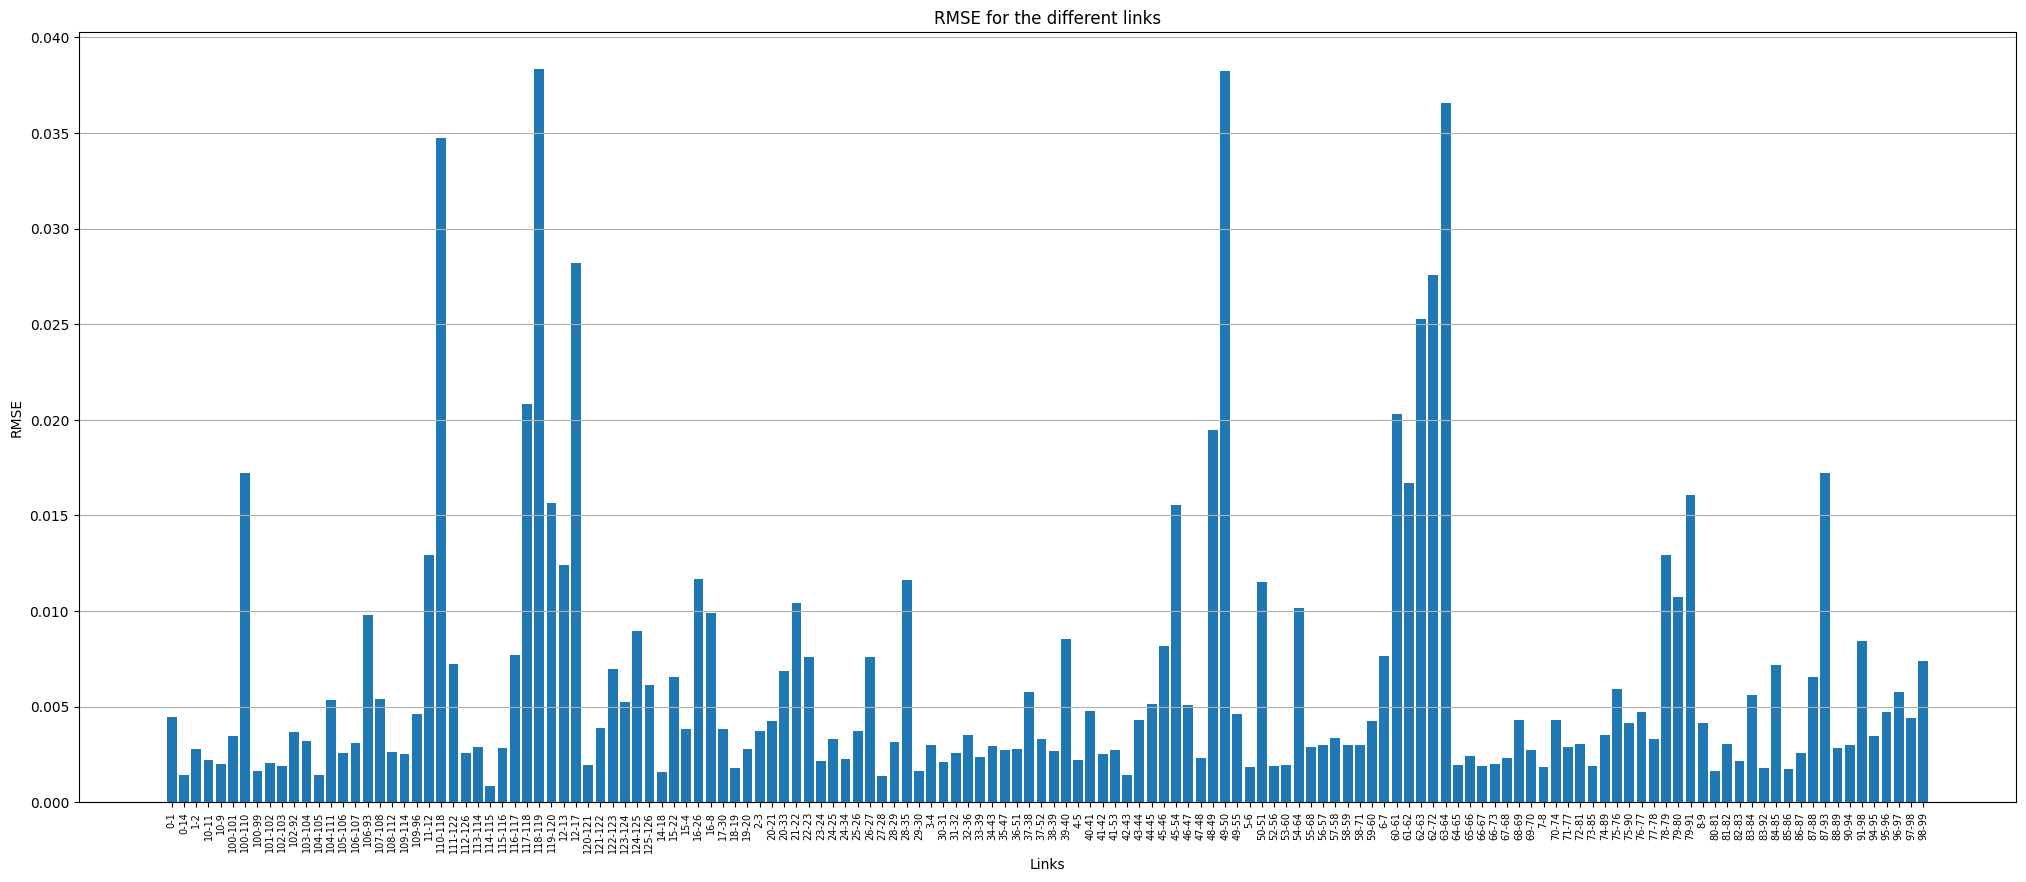

In [34]:
f = open('LauraHandy/Results/Brisbane/FFT_estimation/5_days/Not_normalized/results.json')
data = json.load(f)
f.close()

links = []
values = []
for key in data:
    links.append(key)
    values.append(data[key]['Future_rmse_estimation_error'])

plt.figure(figsize = (25, 10))

plt.bar(links, values)

plt.xlabel("Links")
plt.ylabel("RMSE")
plt.xticks(rotation = 90, fontsize=7)
plt.title("RMSE for the different links")
plt.grid(axis = 'y')
plt.show()

In [ ]:
# Parameters (User-defined)
days_to_remove = 5  # Number of days to remove from the end for validation
days_to_estimate = 5  # Number of days to estimate into the future
normalize_data = True
deviation_threshold = 0.02  # Threshold for deviation
deviation_count_limit = 3  # Number of deviations to trigger restart
deviation_time_limit = 10 # Number of days until deviation counter restarts
deviation_max_time = 30 # Minimum number of days to use for trainning


files_in_dir = os.listdir('LauraHandy/data/not_normalized/Brisbane/up_to_30-06-2024')
save_path = f'LauraHandy/Results/Brisbane/FFT_estimation/{days_to_estimate}_days/'
pattern = r'_(\d{1,3}-\d{1,3})\.xlsx'

result_dict = {}
data_files = []
for file_name in files_in_dir:
    data_files.append('LauraHandy/data/not_normalized/Brisbane/up_to_30-06-2024/' + file_name)

for file_path in data_files:
    data = pd.read_excel(file_path)
    link = re.search(pattern, file_path).group(1)
    start_index = 0

    if normalize_data:
        save_path_fig = f'{save_path}Normalized/Link_{link}.png'
    else:
        save_path_fig = f'{save_path}/Not_normalized/Link_{link}.png'

    result = get_error_estimation_fft(data, days_to_remove, days_to_estimate, link, normalize_data, False, save_path_fig)

    results_lenght = len(result[link]["Past_estimation_error"])
    deviation_count = 0
    
    



    result_dict.update(get_error_estimation_fft(data, days_to_remove, days_to_estimate, link, normalize_data, False, save_path_fig))
    

if normalize_data:
    save_path_json = f'{save_path}Normalized/results.json'
else:
    save_path_json = f'{save_path}Not_normalized/results.json'

with open(save_path_json, "w") as outfile: 
    json.dump(result_dict, outfile)


In [ ]:
N_remove = 5  # Number of days to remove from the end for validation
N_estimate = 10  # Number of days to estimate into the future
deviation_threshold = 0.02  # Threshold for deviation
deviation_count_limit = 3  # Number of consecutive deviations to trigger restart



result = get_error_estimation_fft(data, N_remove, N_estimate, link, normalize_data, False)

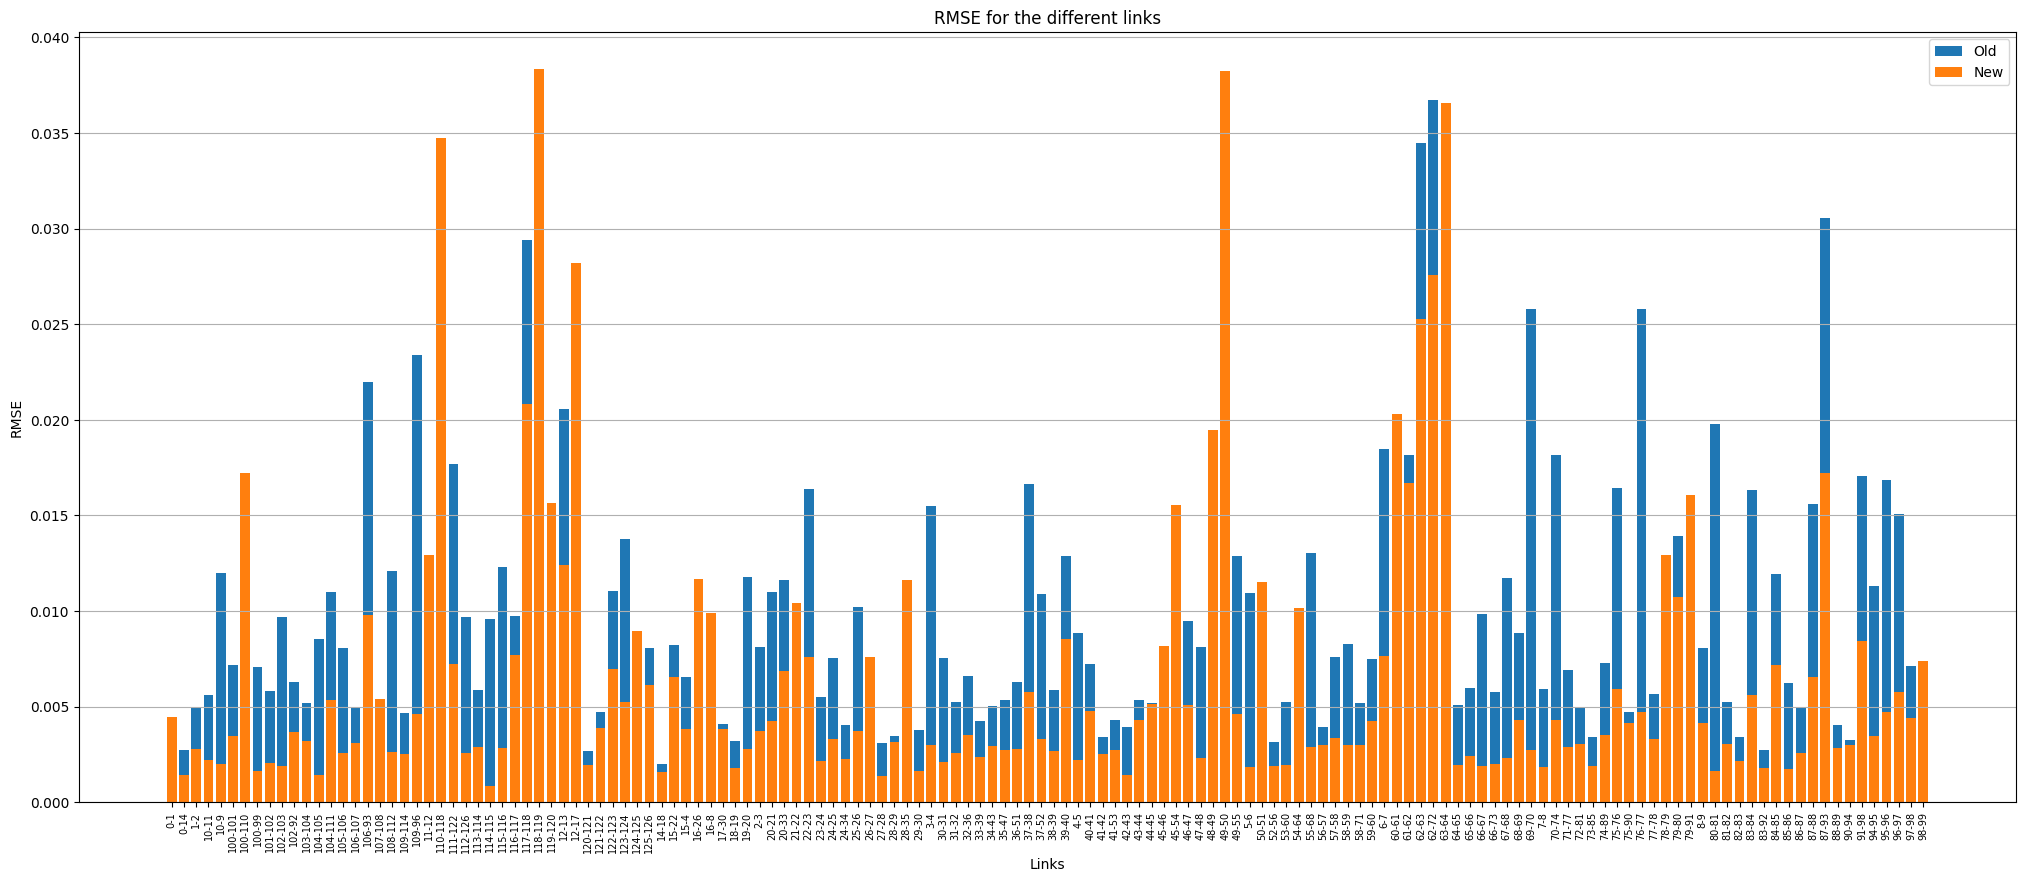